In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, auc
import os, shutil
from sklearn.preprocessing import StandardScaler

###  Calcular médias móveis de transações nos últimos 3, 6 e 12 meses por cliente

In [2]:
#1 - Calcular médias móveis de transações nos últimos 3, 6 e 12 meses por cliente
df = pd.read_csv('transacoes_clientes.csv')

In [ ]:
filtro = df.loc[df['mes'].isin([3, 6, 12])]
print(filtro.groupby('id_cliente')[['valor_total']].mean().sort_values(by='id_cliente', ascending=True))

             valor_total
id_cliente              
1            4466.585000
2           15489.450000
3           15710.840000
4            7816.076667
5           11280.870000
...                  ...
496          8475.500000
497          6956.730000
498          9310.760000
499          3908.720000
500         13054.395000

[460 rows x 1 columns]


### Realizar merge entre bases de perfil, transações e reclamações em um único dataframe

In [ ]:
df_clientes = pd.read_csv('clientes.csv')
df_transacoes = pd.read_csv('transacoes_clientes.csv')
df_reclamacoes = pd.read_csv('reclamacoes.csv')

df_transacoes = df_transacoes.sort_values(['id_cliente', 'mes'], ascending=True)
#print(df_transacoes.head())

df_concatenado = pd.concat([df_clientes, df_transacoes, df_reclamacoes], axis=1, ignore_index=False)
print(df_concatenado.head())


   id_cliente  idade  tempo_relacionamento_meses  numero_produtos  \
0         1.0   31.0                       167.0              1.0   
1         2.0   57.0                       139.0              3.0   
2         3.0   19.0                       233.0              2.0   
3         4.0   33.0                       174.0              5.0   
4         5.0   56.0                       142.0              1.0   

        segmento  id_cliente  mes  quantidade_transacoes  valor_total  \
0  universitario         476    9                     45      6685.86   
1         varejo         279    9                     77        14.52   
2         varejo         402    9                     94      1532.50   
3  universitario         414   10                     18      7049.04   
4         varejo         423   11                     80     15181.30   

   id_cliente       motivo  resolvido  
0        25.0      tarifas        1.0  
1       458.0       outros        1.0  
2        60.0       outros

### Gere um gráfico de barras com a taxa de churn por tipo de produto (cartão, conta, investimento)


In [ ]:
#Criando a coluna tipo_produto 
tipos = ['cartao', 'conta', 'investimento']

df_clientes['tipo_produto'] = np.random.choice(tipos, size=500)

In [6]:
#Criando a coluna churn para o exemplo
# Definindo a probabilidade base
df_concatenado['probabilidade'] = 0.1  # Probabilidade inicial de 10%

# Regra: Reclamações não resolvidas aumentam o risco em 3x 
df_concatenado.loc[df_concatenado['resolvido'] == 0, 'probabilidade'] *= 3

# Regra: Baixa atividade (ex: menos de 20 transações) aumenta o risco 
df_concatenado.loc[df_concatenado['quantidade_transacoes'] < 20, 'probabilidade'] += 0.2

# Criando a coluna Churn binária (Target) baseada na probabilidade calculada
# Isso garante que o target seja entre 15% e 20% conforme o requisito [cite: 21]
df_concatenado['churn'] = (df_concatenado['probabilidade'] > 0.5).astype(int)

In [7]:
#Criando a coluna churn para o exemplo
df_clientes['churn'] = np.random.choice([0, 1], size=500)

In [8]:
df_clientes.head()

,id_cliente,idade,tempo_relacionamento_meses,numero_produtos,segmento,tipo_produto,churn
0,1,31,167,1,universitario,cartao,0
1,2,57,139,3,varejo,investimento,0
2,3,19,233,2,varejo,conta,1
3,4,33,174,5,universitario,investimento,1
4,5,56,142,1,varejo,conta,1


In [9]:
taxa_churn = df_clientes.groupby('tipo_produto')['churn'].mean()
print(taxa_churn)

tipo_produto
cartao          0.479532
conta           0.462963
investimento    0.514970
Name: churn, dtype: float64


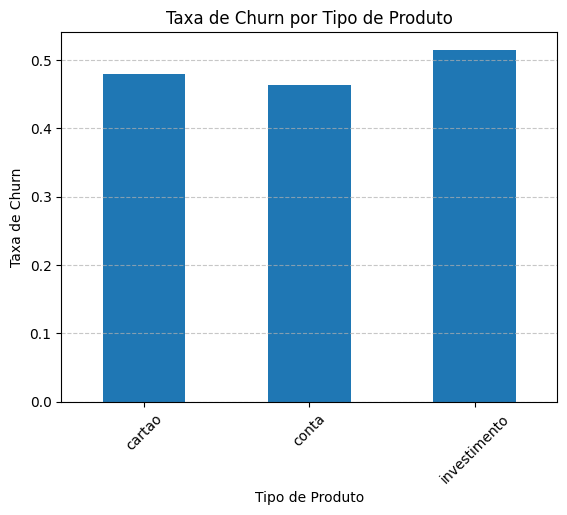

In [10]:
# Plotar o gráfico de barras
taxa_churn.plot(kind='bar')
plt.title('Taxa de Churn por Tipo de Produto')
plt.xlabel('Tipo de Produto')
plt.ylabel('Taxa de Churn')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Gerar regplot mostrando a relação entre tempo de relacionamento e probabilidade de churn

Total de clientes: 500
Clientes ativos no mês 12: 277
Taxa de churn baseada na atividade no mês 12: 44.6000


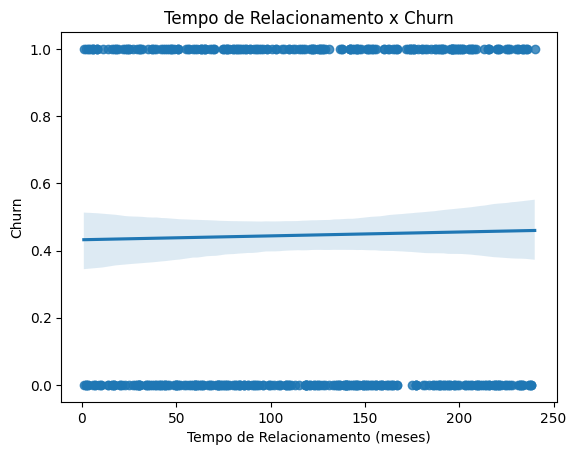

In [11]:
# Identificar clientes ativos no mês 12
clientes_ativos_mes12 = df_transacoes[df_transacoes['mes'] == 12]['id_cliente'].unique()

# Número total de clientes
total_clientes = len(df_clientes)
 
# Número de clientes ativos no mês 12
num_ativos = len(clientes_ativos_mes12)

# Taxa de churn (clientes não ativos no mês 12 / total de clientes)
taxa_churn_mes12 = ((total_clientes - num_ativos) / total_clientes ) * 100

print(f"Total de clientes: {total_clientes}")
print(f"Clientes ativos no mês 12: {num_ativos}")
print(f"Taxa de churn baseada na atividade no mês 12: {taxa_churn_mes12:.4f}")

df_clientes['churn_mes'] = np.where(df_clientes['id_cliente'].isin(clientes_ativos_mes12), 0, 1)

sns.regplot(
    data=df_clientes,
    x='tempo_relacionamento_meses',
    y='churn_mes'
)

plt.title('Tempo de Relacionamento x Churn')
plt.xlabel('Tempo de Relacionamento (meses)')
plt.ylabel('Churn')

plt.show()

### Treinar um modelo de Regressão Logística com AUC -ROC >= 0,80 para prever churn

In [12]:
df_concatenado = pd.concat([df_clientes, df_transacoes, df_reclamacoes], axis=1, ignore_index=False)
df_concatenado.head()

,id_cliente,idade,tempo_relacionamento_meses,numero_produtos,segmento,tipo_produto,churn,churn_mes,id_cliente,mes,quantidade_transacoes,valor_total,id_cliente,motivo,resolvido
0,1.0,31.0,167.0,1.0,universitario,cartao,0.0,0.0,476,9,45,6685.86,25.0,tarifas,1.0
1,2.0,57.0,139.0,3.0,varejo,investimento,0.0,0.0,279,9,77,14.52,458.0,outros,1.0
2,3.0,19.0,233.0,2.0,varejo,conta,1.0,1.0,402,9,94,1532.50,60.0,outros,1.0
3,4.0,33.0,174.0,5.0,universitario,investimento,1.0,1.0,414,10,18,7049.04,270.0,atendimento,1.0
4,5.0,56.0,142.0,1.0,varejo,conta,1.0,1.0,423,11,80,15181.30,300.0,outros,0.0


In [13]:
x = df_concatenado[['id_cliente', 'tempo_relacionamento_meses', 'numero_produtos', 'mes', 'quantidade_transacoes', 'valor_total', 'resolvido']]
y = df_concatenado['churn']

In [14]:
x = x.replace(np.nan, 0, inplace=True)
y = y.replace(np.nan, 0, inplace=True)

In [15]:
display(x)
display(y)

,id_cliente,id_cliente,id_cliente,tempo_relacionamento_meses,numero_produtos,mes,quantidade_transacoes,valor_total,resolvido
0,1.0,476,25.0,167.0,1.0,9,45,6685.86,1.0
1,2.0,279,458.0,139.0,3.0,9,77,14.52,1.0
2,3.0,402,60.0,233.0,2.0,9,94,1532.50,1.0
3,4.0,414,270.0,174.0,5.0,10,18,7049.04,1.0
4,5.0,423,300.0,142.0,1.0,11,80,15181.30,0.0
...,...,...,...,...,...,...,...,...,...
3389,0.0,500,0.0,0.0,0.0,6,62,10260.80,0.0
4896,0.0,500,0.0,0.0,0.0,7,59,19898.66,0.0
1406,0.0,500,0.0,0.0,0.0,8,23,6922.33,0.0
1997,0.0,500,0.0,0.0,0.0,9,50,7979.23,0.0


0       0.0
1       0.0
2       1.0
3       1.0
4       1.0
       ... 
3389    0.0
4896    0.0
1406    0.0
1997    0.0
3639    0.0
Name: churn, Length: 5000, dtype: float64

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [17]:
x_train

,id_cliente,id_cliente,id_cliente,tempo_relacionamento_meses,numero_produtos,mes,quantidade_transacoes,valor_total,resolvido
1250,0.0,410,0.0,0.0,0.0,2,47,6977.30,0.0
2408,0.0,458,0.0,0.0,0.0,7,79,3232.32,0.0
763,0.0,35,0.0,0.0,0.0,6,56,9000.91,0.0
2688,0.0,355,0.0,0.0,0.0,1,84,11840.34,0.0
1378,0.0,407,0.0,0.0,0.0,2,31,17544.09,0.0
...,...,...,...,...,...,...,...,...,...
2064,0.0,432,0.0,0.0,0.0,7,61,10995.28,0.0
466,467.0,499,0.0,20.0,1.0,7,0,19968.77,0.0
2447,0.0,295,0.0,0.0,0.0,4,20,18993.70,0.0
2232,0.0,365,0.0,0.0,0.0,2,51,7936.93,0.0


In [18]:
modelo = LogisticRegression()
modelo.fit(x_train, y_train)

c:\Users\joasoliveira-ieg\OneDrive - Instituto Germinare\Área de Trabalho\Análise de Dados\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
y_probs = modelo.predict_proba(x_test)[:, 1]

In [20]:
# Calcular FPR, TPR e thresholds
auc = roc_auc_score(y_test, y_probs)

# Calcular a área sob a curva (AUC)
#valor_auc = auc(fpr, tpr)
print(f"O valor do AUC é: {auc:.4f}")

O valor do AUC é: 0.9531


# RPA

In [ ]:
# Criando a pasta de relatórios caso não exista
if not os.path.exists('./relatorios_churn'):
    os.makedirs('./relatorios_churn')

# 1. Identificando os Top 20 clientes com maior probabilidade de churn
scaler = StandardScaler()
scaler.fit(x_train)

df_concatenado['probabilidade_modelo'] = modelo.predict_proba(scaler.transform(x))[:, 1]
top_20_risco = df_concatenado.nlargest(20, 'probabilidade_modelo')

# 2. Criando colunas de "Ação Sugerida" e "Motivo" para o RPA
top_20_risco['Ação Sugerida'] = "Oferecer isenção de tarifa e ligar para o cliente"
top_20_risco['Motivo Principal'] = top_20_risco['motivo'].fillna("Baixo Engajamento")

# 3. Selecionando apenas as colunas pedidas no PDF
relatorio_final = top_20_risco[['id_cliente', 'probabilidade_modelo', 'Motivo Principal', 'Ação Sugerida']]

# 4. Salvando em Excel
caminho_arquivo = './relatorios_churn/relatorio_diario_churn.xlsx'
relatorio_final.to_excel(caminho_arquivo, index=False)

print(f"RPA Concluído: Relatório salvo em {caminho_arquivo}")

c:\Users\joasoliveira-ieg\OneDrive - Instituto Germinare\Área de Trabalho\Análise de Dados\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


,id_cliente,idade,tempo_relacionamento_meses,numero_produtos,segmento,tipo_produto,churn,churn_mes,id_cliente,mes,quantidade_transacoes,valor_total,id_cliente,motivo,resolvido,probabilidade_modelo
0,1.0,31.0,167.0,1.0,universitario,cartao,0.0,0.0,476,9,45,6685.86,25.0,tarifas,1.0,0.589754
1,2.0,57.0,139.0,3.0,varejo,investimento,0.0,0.0,279,9,77,14.52,458.0,outros,1.0,0.830220
2,3.0,19.0,233.0,2.0,varejo,conta,1.0,1.0,402,9,94,1532.50,60.0,outros,1.0,0.720179
3,4.0,33.0,174.0,5.0,universitario,investimento,1.0,1.0,414,10,18,7049.04,270.0,atendimento,1.0,0.939922
4,5.0,56.0,142.0,1.0,varejo,conta,1.0,1.0,423,11,80,15181.30,300.0,outros,0.0,0.470043


RPA Concluído: Relatório salvo em ./relatorios_churn/relatorio_diario_churn.xlsx
